In [ ]:
import os
import sys
import time
import joblib
from pathlib import Path

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset

from utils.models import CNNLSTM
from utils.preprocessing import (
    FEATURES,
    load_and_preprocess_data,
    balance_dataset,
)
from utils.evaluation import evaluate_model
from properties import build_properties

In [2]:
# =========================
# Config: Define datasets
# =========================
DATASETS = {
    "ciciot2023": {
        "path": "../data/CICIoT2023/ciciot2023_labeled_conn.tsv",
    },
    "cicids2017": {
        "path": "../data/CICIDS2017/wednesday_labeled.tsv",
    },
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Configured datasets: {list(DATASETS.keys())}")

Device: cuda
Configured datasets: ['ciciot2023', 'cicids2017']


In [3]:
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [4]:
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD"]
df = df_ciciot2023.copy()

for col in [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "missed_bytes",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

duration_safe = df["duration"].replace(0, 1e-6)

df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe
df["orig_byte_rate"] = df["orig_bytes"] / duration_safe
df["pkt_asymmetry"] = df["orig_pkts"] / (df["resp_pkts"] + 1.0)
df["byte_asymmetry"] = df["orig_bytes"] / (df["resp_bytes"] + 1.0)
FEATURES = [
    "proto",
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "conn_state",
    "missed_bytes",
    "history",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
    "orig_pkt_rate",
    "orig_byte_rate",
    "pkt_asymmetry",
    "byte_asymmetry",
]

BATCH_SIZE = 256
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
TEST_SIZE = 0.3
LAMBDA_PROP = 0.5

In [5]:
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,orig_pkt_rate,orig_byte_rate,pkt_asymmetry,byte_asymmetry
0,1.665163e+09,CktBip1sFHNchgO7kb,192.168.137.41,50093,157.249.81.141,443,tcp,-,0.126077,251.0,...,459,0,0,-,6,BENIGN,31.726643,1990.846863,4.000000,251.000000
1,1.665163e+09,CuckeIVEEpWRUL51i,192.168.137.172,41150,52.207.44.110,80,tcp,-,4.780317,0.0,...,104,0,0,-,6,BENIGN,0.418382,0.000000,2.000000,0.000000
2,1.665163e+09,Cgk4rv3Zok2KZiyHij,192.168.137.41,51746,157.249.81.141,80,tcp,http,0.291959,196.0,...,464,5,643,-,6,BENIGN,17.125692,671.327138,0.833333,0.521277
3,1.665163e+09,CVpJpI3GzZ18oGjoCf,192.168.137.41,50096,157.249.81.141,443,tcp,ssl,0.291320,251.0,...,519,5,275,-,6,BENIGN,17.163257,861.595496,0.833333,31.375000
4,1.665163e+09,CnUiCh2UbvrkCSKyDa,192.168.137.41,51749,157.249.81.141,80,tcp,http,0.292739,196.0,...,464,5,643,-,6,BENIGN,17.080061,669.538394,0.833333,0.521277


In [6]:
X = df[FEATURES].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=42,
)

print(len(X_train), len(X_test))

1295590 555254


In [7]:
# Balance dataset
X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)
print(f"X_train_balanced shape: {X_train_balanced.shape}")
print("y_train_balanced distribution:")
print(y_train_balanced.value_counts())

X_train_balanced shape: (479156, 16)
y_train_balanced distribution:
label
BENIGN            239578
DOS_HTTP_FLOOD    239578
Name: count, dtype: int64


In [9]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_balanced)
y_test_enc = label_encoder.transform(y_test)

X_train_bal = X_train_balanced.copy()
X_test = X_test.copy()

categorical_cols = X_train_bal.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical:", categorical_cols)

ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

if len(categorical_cols) > 0:
    X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
    X_test[categorical_cols] = ordinal_encoder.transform(X_test[categorical_cols])

Categorical: ['proto', 'service', 'conn_state', 'history']


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal[FEATURES])
X_test_scaled = scaler.transform(X_test[FEATURES])

print(X_train_scaled.shape, X_test_scaled.shape)

(479156, 16) (555254, 16)


In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [12]:
model = CNNLSTM(n_features=len(FEATURES)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [13]:
properties = build_properties(
    device=device,
    scaler=scaler,
    feature_names=FEATURES,
)

print(properties)

# Test property loss works as expected

In [ ]:
x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

prop_loss, prop_stats = properties.compute_loss(model, x_batch)

print("Initial property loss:", prop_loss.item())
print("Property stats:", prop_stats)

Initial property loss: 0.0002659867750480771
Property stats: {'constraint_0_loss': 0.0, 'constraint_0_sat': 1.0, 'constraint_1_loss': 0.0005319735500961542, 'constraint_1_sat': 0.95703125}


In [15]:
history = []

for epoch in range(NUM_EPOCHS):
    model.train()

    pred_losses = []
    prop_losses = []
    last_stats = {}

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        pred_loss = criterion(logits, y_batch)

        # PROPERTY INJECTION
        prop_loss, prop_stats = properties.compute_loss(model, x_batch)

        # COMBINED LOSS
        loss = pred_loss + LAMBDA_PROP * prop_loss

        loss.backward()
        optimizer.step()

        pred_losses.append(pred_loss.item())
        prop_losses.append(prop_loss.item())
        last_stats = prop_stats

    avg_pred_loss = float(np.mean(pred_losses))
    avg_prop_loss = float(np.mean(prop_losses))

    history.append({
        "epoch": epoch + 1,
        "pred_loss": avg_pred_loss,
        "prop_loss": avg_prop_loss,
        **last_stats,
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"pred_loss={avg_pred_loss:.4f} | "
        f"prop_loss={avg_prop_loss:.4f}"
    )

Epoch 01 | pred_loss=0.1013 | prop_loss=0.0461
Epoch 02 | pred_loss=0.0889 | prop_loss=0.0470
Epoch 03 | pred_loss=0.0875 | prop_loss=0.0471
Epoch 04 | pred_loss=0.0863 | prop_loss=0.0472
Epoch 05 | pred_loss=0.0857 | prop_loss=0.0472
Epoch 06 | pred_loss=0.0850 | prop_loss=0.0472
Epoch 07 | pred_loss=0.0847 | prop_loss=0.0472
Epoch 08 | pred_loss=0.0844 | prop_loss=0.0472
Epoch 09 | pred_loss=0.0840 | prop_loss=0.0473
Epoch 10 | pred_loss=0.0836 | prop_loss=0.0473


In [ ]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = model(x_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long().cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().astype(int))

y_true_labels = label_encoder.inverse_transform(np.array(all_true))
y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

                precision    recall  f1-score   support

        BENIGN     0.8990    0.9702    0.9332    102677
DOS_HTTP_FLOOD     0.9931    0.9753    0.9841    452577

      accuracy                         0.9743    555254
     macro avg     0.9460    0.9727    0.9587    555254
  weighted avg     0.9757    0.9743    0.9747    555254

[[ 99621   3056]
 [ 11198 441379]]



=== CNNLSTM with Properties Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8990    0.9702    0.9332    102677
DOS_HTTP_FLOOD     0.9931    0.9753    0.9841    452577

      accuracy                         0.9743    555254
     macro avg     0.9460    0.9727    0.9587    555254
  weighted avg     0.9757    0.9743    0.9747    555254


=== Per-Label Accuracy ===

BENIGN: 0.9702
DOS_HTTP_FLOOD: 0.9753


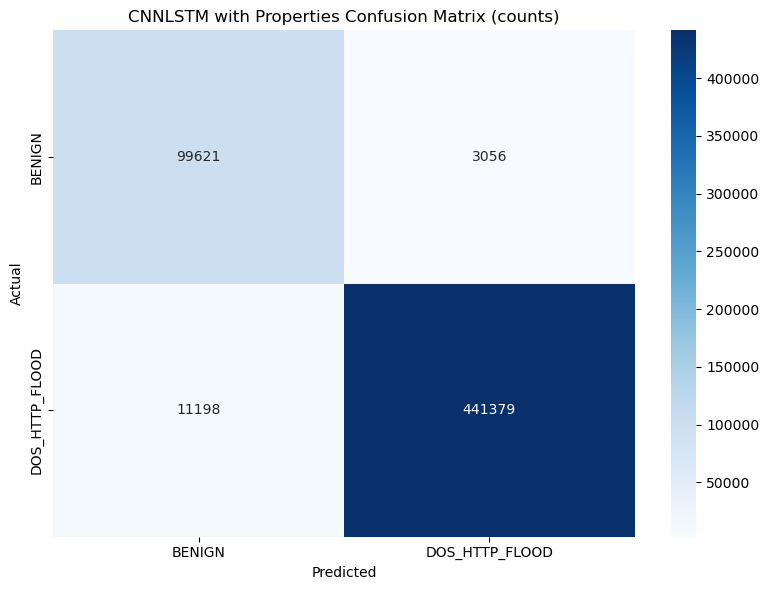

{'BENIGN': {'precision': 0.8989523457168898,
  'recall': 0.9702367618843558,
  'f1-score': 0.9332352830966388,
  'support': 102677.0},
 'DOS_HTTP_FLOOD': {'precision': 0.993123853881895,
  'recall': 0.9752572490427044,
  'f1-score': 0.9841094656481741,
  'support': 452577.0},
 'accuracy': 0.9743288657083065,
 'macro avg': {'precision': 0.9460380997993924,
  'recall': 0.9727470054635301,
  'f1-score': 0.9586723743724065,
  'support': 555254.0},
 'weighted avg': {'precision': 0.975709755210191,
  'recall': 0.9743288657083065,
  'f1-score': 0.974701864006684,
  'support': 555254.0}}

In [17]:
evaluate_model(y_true_labels, y_pred_labels, model_name="CNNLSTM with Properties")

In [23]:
# ===== SAVE MODEL =====
os.makedirs("models", exist_ok=True)
save_path = f"models/cnnlstm_property_ciciot2023.joblib"

joblib.dump(
    {
        "model": model.cpu(),
        "ordinal_encoder": ordinal_encoder,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features": FEATURES,
        "categorical_cols": list(categorical_cols),
    },
    save_path,
)

print(f"\nSaved model to: {save_path}")


Saved model to: models/cnnlstm_property_ciciot2023.joblib


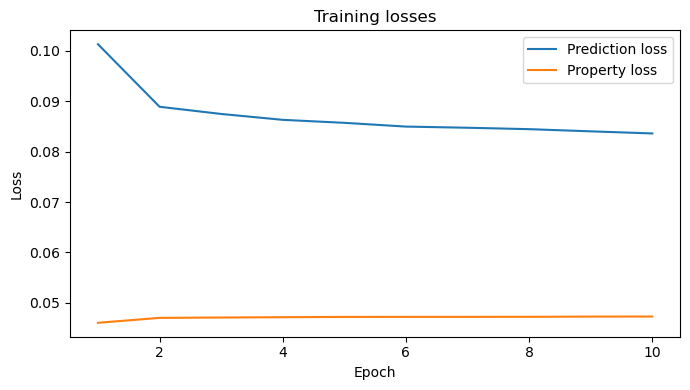

In [22]:
history_df = pd.DataFrame(history)
history_df
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["pred_loss"], label="Prediction loss")
plt.plot(history_df["epoch"], history_df["prop_loss"], label="Property loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.tight_layout()
plt.show()